Memproses 9 gambar...

File              : 01_HighQuality_Enhanced.jpg
Ukuran Asli       : 2481 x 3506 piksel
Jumlah Piksel TTD : 48376
Rasio Piksel      : 7.41%
Status            : SIGNATURE PRESENT

Hasil Crop Area Kanan Atas:


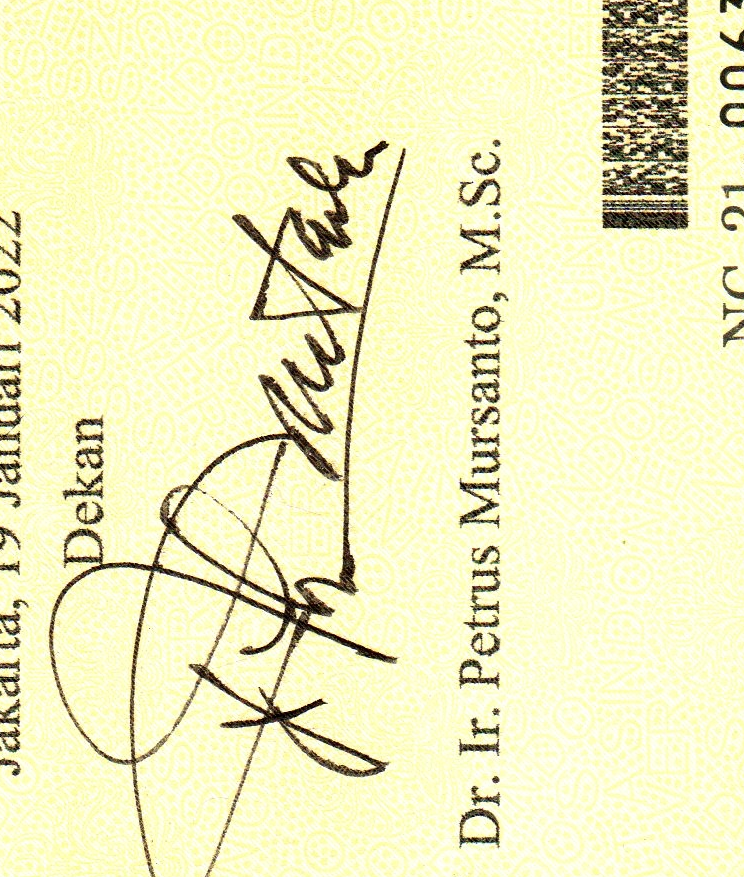



File              : 02_LowContrast.jpg
Ukuran Asli       : 2481 x 3506 piksel
Jumlah Piksel TTD : 48933
Rasio Piksel      : 7.50%
Status            : SIGNATURE PRESENT

Hasil Crop Area Kanan Atas:


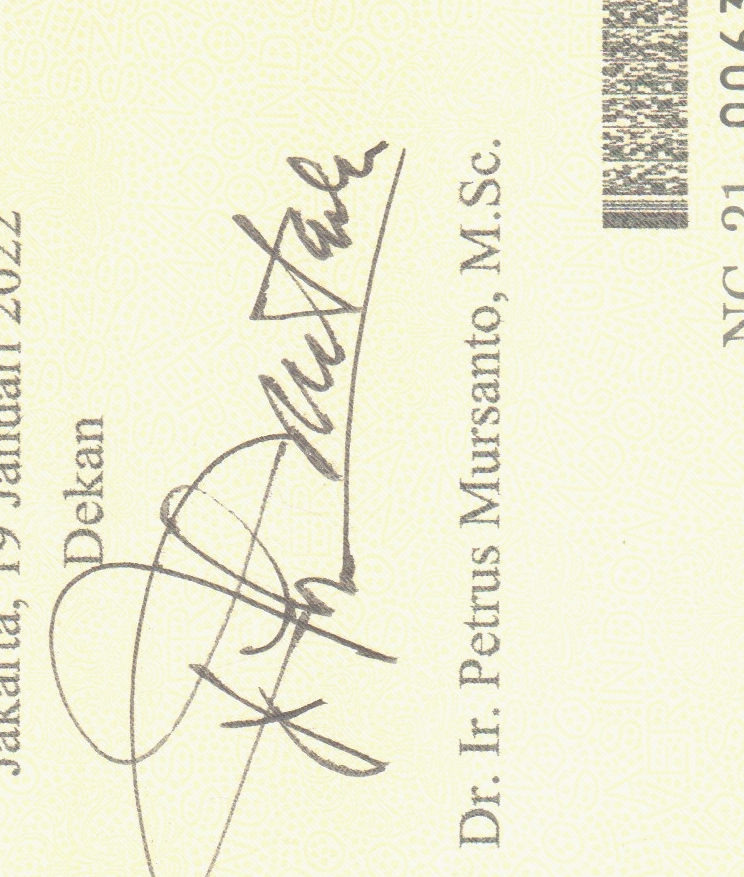



File              : 03_Blurred.jpg
Ukuran Asli       : 2481 x 3506 piksel
Jumlah Piksel TTD : 76256
Rasio Piksel      : 11.69%
Status            : SIGNATURE PRESENT

Hasil Crop Area Kanan Atas:


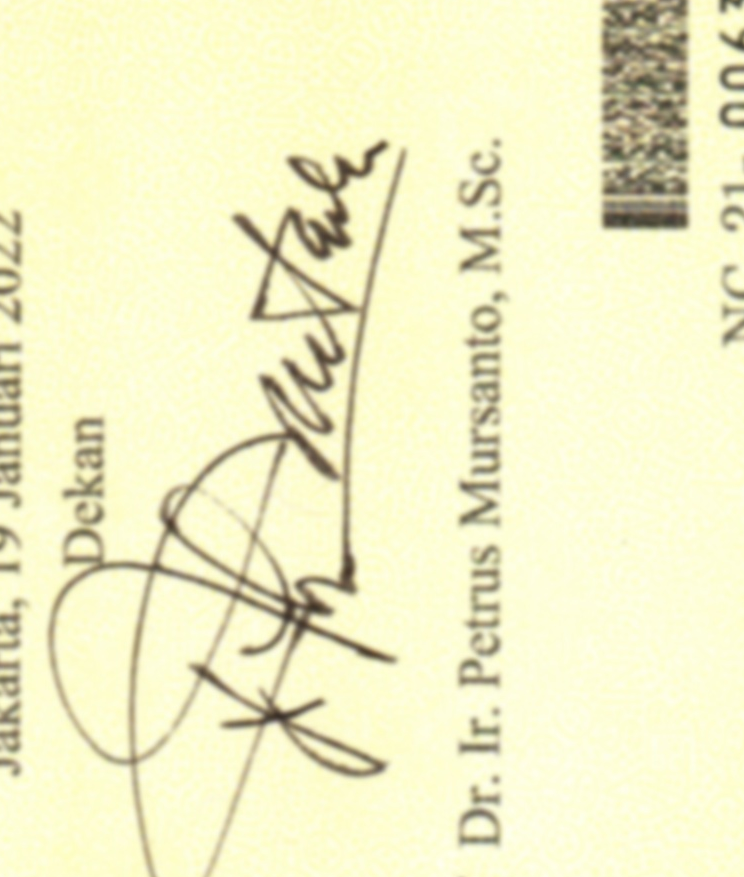



File              : 04_HighNoise.jpg
Ukuran Asli       : 2481 x 3506 piksel
Jumlah Piksel TTD : 46717
Rasio Piksel      : 7.16%
Status            : SIGNATURE PRESENT

Hasil Crop Area Kanan Atas:


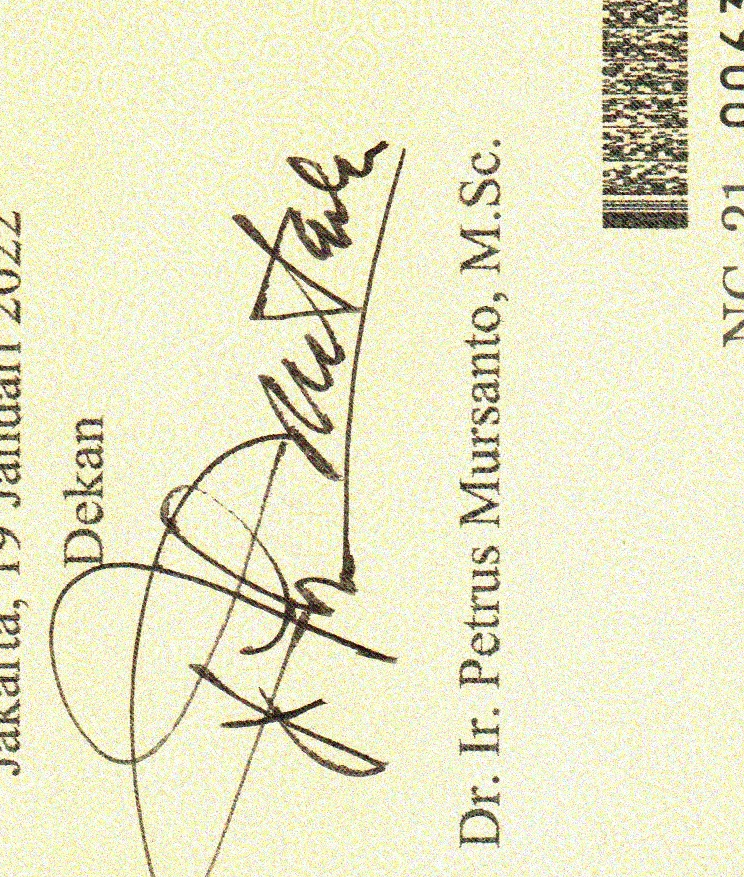



File              : 05_LowResolution_Upsampled.jpg
Ukuran Asli       : 2481 x 3506 piksel
Jumlah Piksel TTD : 60048
Rasio Piksel      : 9.20%
Status            : SIGNATURE PRESENT

Hasil Crop Area Kanan Atas:


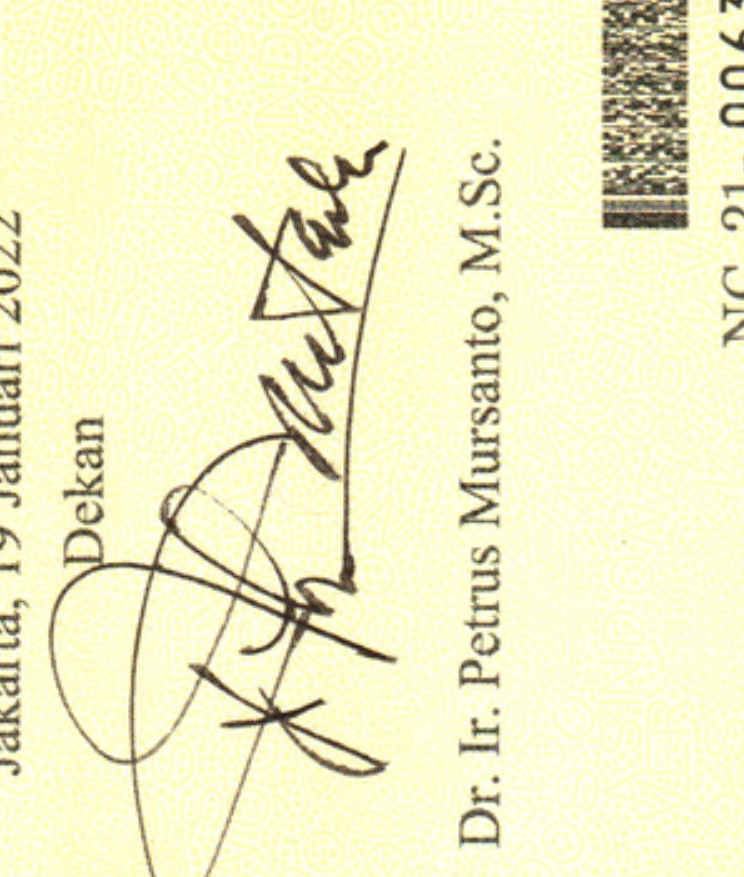



File              : 06_Faded_Underexposed.jpg
Ukuran Asli       : 2481 x 3506 piksel
Jumlah Piksel TTD : 49777
Rasio Piksel      : 7.63%
Status            : SIGNATURE PRESENT

Hasil Crop Area Kanan Atas:


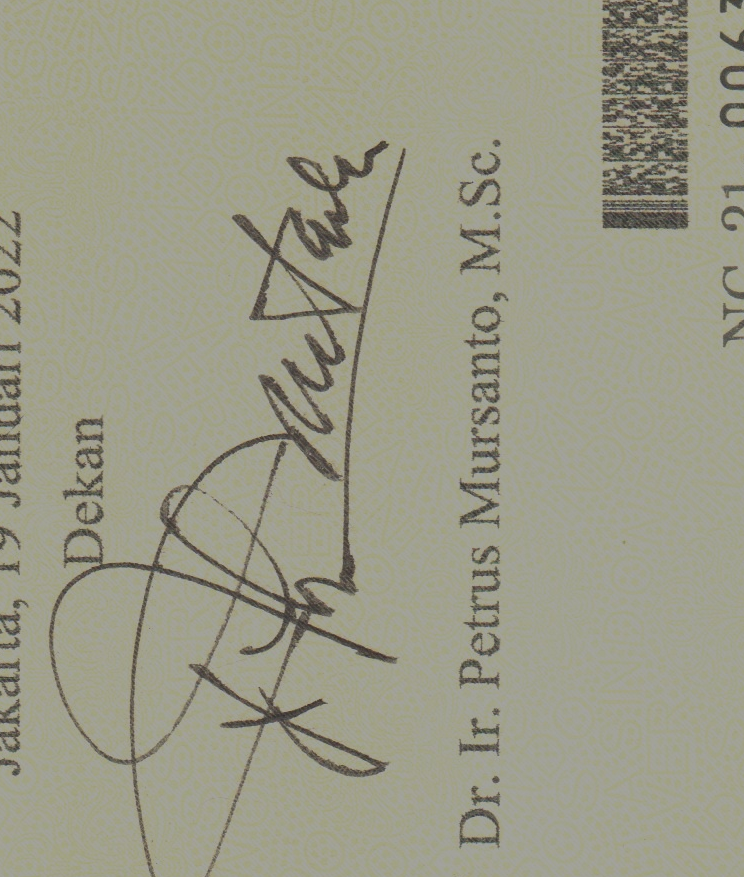



File              : 07_ColorShift_WarmTint.jpg
Ukuran Asli       : 2481 x 3506 piksel
Jumlah Piksel TTD : 49062
Rasio Piksel      : 7.52%
Status            : SIGNATURE PRESENT

Hasil Crop Area Kanan Atas:


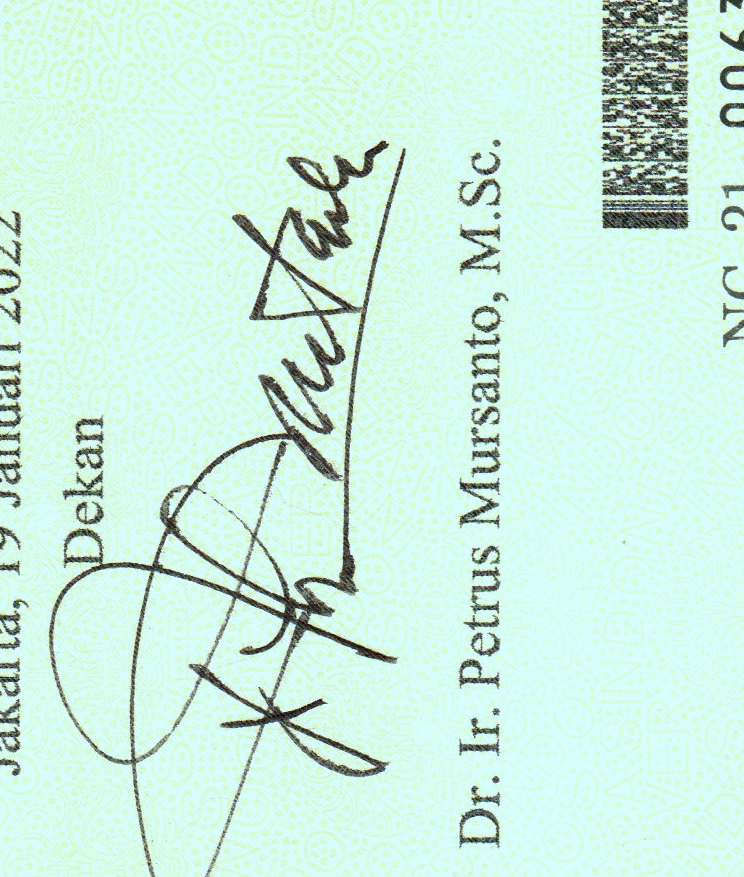



File              : 08_JPEGCompression_Artifacts.jpg
Ukuran Asli       : 2481 x 3506 piksel
Jumlah Piksel TTD : 50344
Rasio Piksel      : 7.72%
Status            : SIGNATURE PRESENT

Hasil Crop Area Kanan Atas:


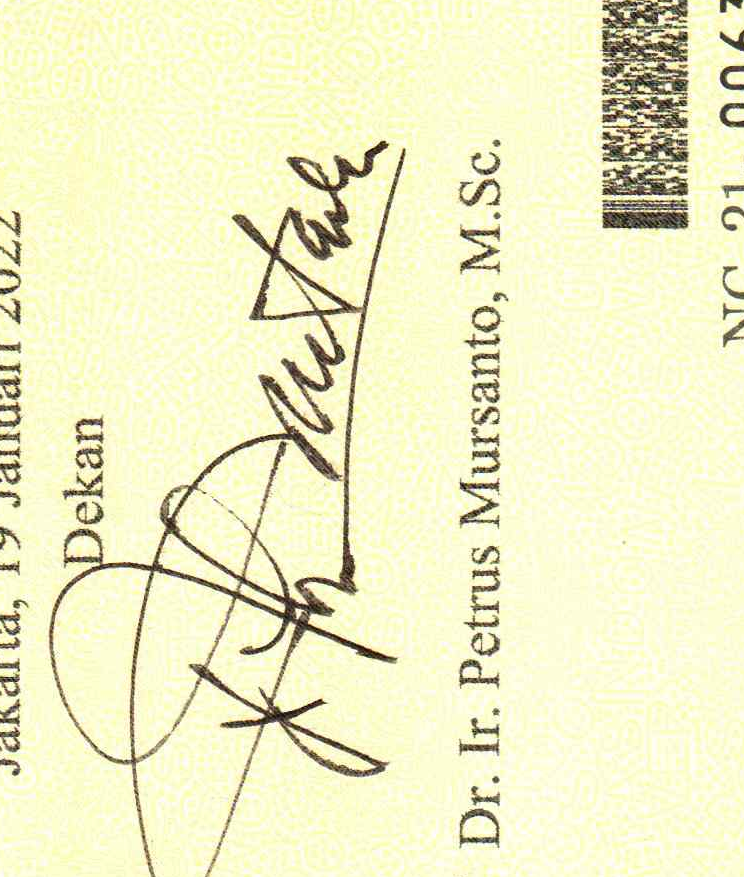



File              : 09_CombinedDegradation.jpg
Ukuran Asli       : 2481 x 3506 piksel
Jumlah Piksel TTD : 57502
Rasio Piksel      : 8.81%
Status            : SIGNATURE PRESENT

Hasil Crop Area Kanan Atas:


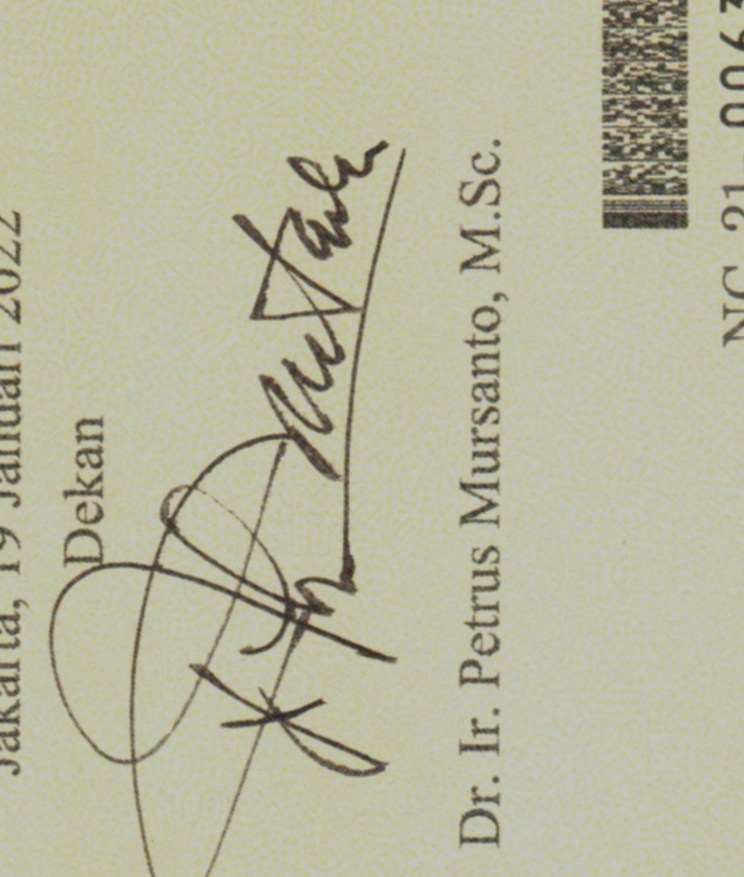

In [2]:
import cv2
import numpy as np
import glob
import os
from google.colab.patches import cv2_imshow


# ==========================================================
# FUNGSI DETEKSI TANDA TANGAN
# ==========================================================

def detect_signature(image_path):

    # Membaca gambar
    img = cv2.imread(image_path)

    if img is None:
        print(f"Gagal membaca {image_path}")
        return

    # Ukuran gambar
    h, w = img.shape[:2]

    # ======================================================
    # CROP AREA TANDA TANGAN KANAN ATAS
    # ======================================================

    y_start = int(h * 0.10)
    y_end   = int(h * 0.35)

    x_start = int(w * 0.65)
    x_end   = int(w * 0.95)

    cropped_img = img[
        y_start:y_end,
        x_start:x_end
    ]

    # ======================================================
    # GRAYSCALE
    # ======================================================

    gray = cv2.cvtColor(
        cropped_img,
        cv2.COLOR_BGR2GRAY
    )

    # ======================================================
    # GLOBAL THRESHOLD
    # ======================================================

    _, global_thresh = cv2.threshold(
        gray,
        127,
        255,
        cv2.THRESH_BINARY_INV
    )

    # ======================================================
    # OTSU THRESHOLD
    # ======================================================

    _, otsu_thresh = cv2.threshold(
        gray,
        0,
        255,
        cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU
    )

    # ======================================================
    # MORPHOLOGY
    # ======================================================

    kernel = np.ones((3, 3), np.uint8)

    # Opening
    opening = cv2.morphologyEx(
        otsu_thresh,
        cv2.MORPH_OPEN,
        kernel
    )

    # Closing
    closing = cv2.morphologyEx(
        opening,
        cv2.MORPH_CLOSE,
        kernel
    )

    # ======================================================
    # PERHITUNGAN FOREGROUND
    # ======================================================

    foreground_pixels = cv2.countNonZero(closing)

    total_pixels = (
        closing.shape[0] *
        closing.shape[1]
    )

    pixel_ratio = (
        foreground_pixels /
        total_pixels
    ) * 100

    # ======================================================
    # KEPUTUSAN
    # ======================================================

    if pixel_ratio > 1.5:
        status = "SIGNATURE PRESENT"
    else:
        status = "SIGNATURE ABSENT"

    # ======================================================
    # TAMPILKAN HASIL
    # ======================================================

    print("=" * 50)
    print(f"File              : {os.path.basename(image_path)}")
    print(f"Ukuran Asli       : {w} x {h} piksel")
    print(f"Jumlah Piksel TTD : {foreground_pixels}")
    print(f"Rasio Piksel      : {pixel_ratio:.2f}%")
    print(f"Status            : {status}")

    print("\nHasil Crop Area Kanan Atas:")
    cv2_imshow(cropped_img)

    print("\n")



# ==========================================================
# MEMBACA SEMUA GAMBAR
# ==========================================================

test_images = (
    glob.glob("/content/*.jpg") +
    glob.glob("/content/*.jpeg") +
    glob.glob("/content/*.png")
)

if len(test_images) == 0:

    print("Tidak ada gambar ditemukan di /content!")

else:

    print(
        f"Memproses {len(test_images)} gambar...\n"
    )

    for img_path in sorted(test_images):

        detect_signature(img_path)